C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9275 - loss: 0.2526 - val_accuracy: 0.9511 - val_loss: 0.1712
Epoch 2/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9669 - loss: 0.1088 - val_accuracy: 0.9571 - val_loss: 0.1568
Epoch 3/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9775 - loss: 0.0742 - val_accuracy: 0.9626 - val_loss: 0.1645
Epoch 4/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9837 - loss: 0.0532 - val_accuracy: 0.9652 - val_loss: 0.1496
Epoch 5/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9873 - loss: 0.0405 - val_accuracy: 0.9658 - val_loss: 0.1649
Epoch 6/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9875 - loss: 0.0427 - val_accuracy: 0.9649 - val_loss: 0.1929
Epoch 7/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9899 - loss: 0.0304 - val_accuracy: 0.9663 - val_loss: 0.1956
Epoch 8/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9913 - lo

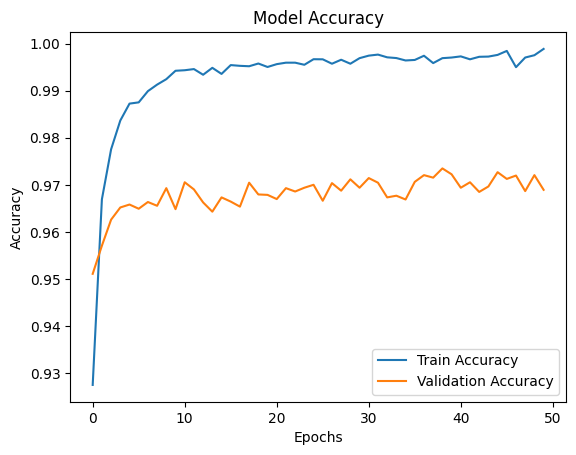

438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Sample 1
True Label: 8
Predicted Label: 8

Sample 2
True Label: 4
Predicted Label: 4

Sample 3
True Label: 8
Predicted Label: 8

Sample 4
True Label: 7
Predicted Label: 7

Sample 5
True Label: 7
Predicted Label: 7



In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()


X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)


X = X.reshape(X.shape[0], -1)


y = tf.keras.utils.to_categorical(y)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = tf.keras.Sequential([
    Dense(128,activation='relu',input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(y.shape[1], activation='softmax')
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history = model.fit( X_train,y_train,epochs=50, batch_size=32, validation_split=0.2, verbose=1)


loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()


def visualize_predictions(model, X_test, y_test, num_samples=5):
    predictions = model.predict(X_test)

    y_pred = np.argmax(predictions, axis=1)
    y_test = np.argmax(y_test, axis=1)

    for i in range(num_samples):
        print(f"Sample {i+1}")
        print(f"True Label: {y_test[i]}")
        print(f"Predicted Label: {y_pred[i]}")
        print()

visualize_predictions(model, X_test, y_test)